# Langevin Monte Carlo on a Bayesian Logistic Posterior
### A controlled comparison of six samplers — and a negative control that overturns the headline

![Python](https://img.shields.io/badge/python-3.9%2B-blue)
![NumPy](https://img.shields.io/badge/numpy-vectorised-013243)
![License](https://img.shields.io/badge/license-MIT-green)
![Reproducible](https://img.shields.io/badge/seeds-fixed-success)

---

## Abstract

Six Langevin-type samplers — **Overdamped**, **Underdamped**, **High-Order**,
**Hessian-Free**, **Mirror**, and **Non-Reversible** — are compared on the
posterior of a Bayesian logistic regression model fitted to the Wisconsin
Breast Cancer dataset. Each sampler is given an identical starting point, an
identical per-iteration gradient budget, and an individually tuned step size.
Under this protocol all five non-overdamped samplers dominate the Overdamped
baseline at **every** iteration $k \ge 1$.

The notebook then runs the experiment that this kind of comparison usually
omits. The baseline is held at the step size it was originally given,
$h = 3\times10^{-4}$, while the challengers are tuned. **Granting Overdamped the
same tuning budget erases the entire effect**: a swept Overdamped reaches
$0.9789$ final accuracy, matching the best challenger, and at $h = 0.03$ it
reaches $0.9816$ and beats all five. The reported margin is therefore a
*step-size* artefact, not evidence of an algorithmic advantage.

The intended contribution is methodological: on this problem test accuracy
saturates within one or two test points of the MAP estimate ($0.9737$), so the
metric has no resolving power left, and any ranking it produces is an artefact
of tuning effort rather than of the dynamics.

---

## Key results

| | |
|---|---|
| **Headline (tuned challengers vs. untuned baseline)** | 5 / 5 samplers strictly above Overdamped for all $k \ge 1$ |
| **After the negative control (both tuned)** | 0 / 5 — a swept Overdamped matches or beats every challenger |
| **MAP / sklearn ceiling on this split** | $0.9737$ |
| **Resolution of the metric** | 114 test points, so 1 misclassification $= 0.0088$ accuracy |
| **Conclusion** | test accuracy cannot rank these samplers on this problem |

## Contents

| § | Section | Cell |
|---|---|---|
| 1 | [Target distribution and experimental protocol](#1) | code |
| 2 | [The six samplers and their discretisations](#2) | code |
| 3 | [Dominance table](#3) | code |
| 4 | [Convergence figure](#4) | code |
| 5 | [Negative control: tuning the baseline too](#5) | code |
| 6 | [Discussion, limitations, and what would settle it](#6) | — |

---


<a id="1"></a>
## 1. Target distribution and experimental protocol

### 1.1 The posterior

Let $X \in \mathbb{R}^{n \times d}$ be the design matrix, $y \in \{0,1\}^n$ the
labels, and $\sigma(t) = (1 + e^{-t})^{-1}$. With a Gaussian prior
$\beta \sim \mathcal{N}\!\left(0, \tfrac{\lambda}{2} I\right)$, the negative log
posterior — the potential $U$ that every sampler below descends — is

$$
U(\beta) \;=\; -\sum_{i=1}^{n}\Big[\, y_i \log \sigma(x_i^\top \beta) + (1-y_i)\log\big(1 - \sigma(x_i^\top \beta)\big) \Big] \;+\; \frac{1}{\lambda}\lVert \beta \rVert_2^2 ,
$$

$$
\nabla U(\beta) \;=\; -X^\top\big(y - \sigma(X\beta)\big) \;+\; \frac{2}{\lambda}\,\beta .
$$

$U$ is smooth and **strictly convex** (the $\ell_2$ term makes
$\nabla^2 U \succeq \tfrac{2}{\lambda} I$), so the posterior is log-concave and
unimodal. Every sampler below targets $\pi(\beta) \propto e^{-U(\beta)}$; they
differ only in the dynamics used to reach it.

With $\lambda = 10$ the prior standard deviation is $\sqrt{\lambda/2} = \sqrt{5} \approx 2.236$.

### 1.2 What this cell sets up

| Component | Role |
|---|---|
| `T = 21`, `N_RUNS = 10`, `SEEDS` | 21 update steps, 10 independent repetitions for uncertainty bands |
| `load_breast_cancer` + `preprocessing.scale` | 569 samples, 30 features, standardised; an 80/20 split with `random_state=42` gives 455 train / 114 test |
| `_sigmoid` | **Branch-stable** logistic function: it evaluates $e^{-z}$ for $z \ge 0$ and $e^{z}$ otherwise, so neither branch can overflow. The naive `1/(1+np.exp(-z))` overflows for $z \lesssim -710$, which a sampler taking large steps will reach |
| `gradient` | The closed form above, as a single BLAS call. Agrees with the original element-wise loop to $\sim 10^{-13}$ |
| `accuracy` | Uses $\sigma(x^\top\beta) \ge \tfrac12 \iff x^\top\beta \ge 0$, avoiding the transcendental entirely |
| `init_beta` | $\beta_0 \sim \mathcal{N}(0, I)$, seeded — the **same** starting point for all six samplers at a given seed |
| `J_BASE` | A fixed skew-symmetric $J = A - A^\top$ for the non-reversible drift |

### 1.3 Three design decisions that make the comparison fair

**Vectorisation is a methodological choice, not just an optimisation.** The
$\mathcal{O}(100\times)$ speed-up is what makes an honest hyperparameter search
affordable at all; without it, one is forced to compare each method at whatever
step size it happened to ship with.

**A common initialisation.** The original code gave each sampler its own
initialisation scale, from $0.01$ to $0.8$. A sampler started at $0.01\,\mathcal{N}(0,I)$
begins far closer to the mode than one started at $0.8\,\mathcal{N}(0,I)$, so
much of the apparent ranking measured the initialisation rather than the
dynamics. Here every sampler starts from an identical $\beta_0$ with momenta at
zero.

**A fixed $J$ across seeds.** Redrawing the skew-symmetric matrix each run would
add a second, uncontrolled source of variance to the non-reversible sampler
alone. Fixing it isolates the effect of the drift from the effect of which $J$
was drawn.

> **Common random numbers.** Because `init_beta` seeds the global NumPy RNG,
> all six samplers share both $\beta_0$ *and* the subsequent noise stream for a
> given seed. This is a variance-reduction technique: differences between
> curves reflect the dynamics, not different realisations of the driving noise.


In [1]:
# -*- coding: utf-8 -*-
"""
Langevin algorithm comparison on Bayesian logistic regression (breast cancer).

Goal of this version: put every sampler on an equal footing and tune the five
non-overdamped samplers so that each one beats Overdamped Langevin at *every*
iteration, not just at the end.

Three changes make that comparison meaningful:
  1. Vectorized gradient / accuracy (identical math, ~100x faster) so a real
     hyperparameter sweep is affordable.
  2. A COMMON initialization for all six samplers: beta0 ~ N(0, I), momenta at
     zero. In the original script each sampler had its own init scale (0.01 to
     0.8), which by itself accounted for most of the apparent ranking.
  3. Per-sampler step sizes chosen by grid search under the explicit constraint
     "dominate overdamped at every iteration k".
"""
import numpy as np
import math
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn import preprocessing

# ─── Shared Setup ────────────────────────────────────────────────────────────
T      = 21
lam    = 10
N_RUNS = 10                      # independent runs for confidence bands
SEEDS  = list(range(N_RUNS))

cancer = load_breast_cancer()
x_all  = np.insert(cancer.data, 0, 1, axis=1)
x_all  = preprocessing.scale(x_all)
dim    = x_all.shape[1]          # 31  (30 features + bias)

X_train, X_test, y_train, y_test = train_test_split(
    x_all, cancer.target, test_size=0.2, random_state=42
)

def _sigmoid(z):
    """Overflow-safe logistic function."""
    out = np.empty_like(z, dtype=float)
    pos = z >= 0
    out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
    ez = np.exp(z[~pos])
    out[~pos] = ez / (1.0 + ez)
    return out

def gradient(beta, X=None, y=None, lam=lam):
    """Gradient of the negative log posterior. Vectorized; matches the
    original element-wise loop to ~1e-13."""
    X = X_train if X is None else X
    y = y_train if y is None else y
    h = _sigmoid(X @ beta)
    return -X.T @ (y - h) + (2.0 / lam) * beta

def accuracy(beta, X=None, y=None):
    """sigmoid(x.beta) >= 0.5  is exactly  x.beta >= 0."""
    X = X_test if X is None else X
    y = y_test if y is None else y
    return float(np.mean(((X @ beta) >= 0).astype(int) == y))

def init_beta(seed):
    """Common starting point for every sampler."""
    np.random.seed(seed)
    return np.random.normal(0, 1, dim)

# Fixed skew-symmetric J shared by all seeds, so the non-reversible drift is
# the same perturbation in every run (the original drew a new J per seed).
_Aj    = np.random.default_rng(12345).random((dim, dim))
J_BASE = _Aj - _Aj.T

<a id="2"></a>
## 2. The six samplers and their discretisations

All six are **unadjusted** (no Metropolis–Hastings correction) explicit
discretisations, each using exactly **one gradient evaluation per iteration**.
That last point is what makes the $x$-axis an honest compute axis: iteration
count *is* gradient count, the dominant cost in any realistic problem.

### 2.1 Continuous-time dynamics

| Sampler | SDE | Discretisation in the code |
|---|---|---|
| **Overdamped** | $d\beta = -\nabla U\,dt + \sqrt{2}\,dW$ | $\beta \leftarrow \beta - h\nabla U + \sqrt{2h}\,z$ |
| **Underdamped** | $d\beta = p\,dt,\quad dp = -\nabla U\,dt - \gamma p\,dt + \sqrt{2\gamma}\,dW$ | momentum first, then position (symplectic Euler) |
| **High-Order** | $d\beta = p\,dt,\ dp = -\nabla U dt + \gamma r\,dt,\ dr = -\gamma p\,dt - \alpha r\,dt + \sqrt{2\alpha}\,dW$ | a third-order chain $\beta \leftarrow p \leftarrow r$ |
| **Hessian-Free** | $d\beta = r\,dt - \gamma\nabla U dt + \sqrt{2\gamma}\,dW,\quad dr = -\alpha r\,dt - \nabla U dt + \sqrt{2\alpha}\,dW$ | two **independent** noise draws per step |
| **Mirror** | $d\xi = -\nabla U\,dt + \sqrt{2}\,dW$ with $\xi = \nabla\varphi(\beta)$ | $\varphi'(\beta) = \beta^3$, inverted by the signed cube root |
| **Non-Reversible** | $d\beta = -(I + J)\nabla U\,dt + \sqrt{2}\,dW$, $J^\top = -J$ | $J$ fixed and skew-symmetric |

Two of these deserve comment.

**Non-Reversible.** Because $J$ is skew-symmetric, the added drift is divergence-free
with respect to $\pi$: $\nabla\!\cdot\!\big(J\nabla U\, e^{-U}\big) = 0$. The
invariant measure is therefore *unchanged*, but detailed balance is broken,
which can strictly reduce the asymptotic variance. It is a rare case of a free
lunch — provided $J$ is chosen well.

**Mirror.** The dual variable $\xi = \nabla\varphi(\beta)$ evolves by a plain
Langevin step and is mapped back by $(\nabla\varphi)^{-1}$. With
$\varphi'(\beta) = \beta^3$ the inverse is $\mathrm{sign}(\xi)|\xi|^{1/3}$, a
strong contraction: a coordinate of size $10^3$ returns as size $10$. This is
why Mirror cannot be made to converge gradually (see §2.3) — and see
[§6.2](#6) for an important caveat about this particular discretisation.

### 2.2 The symplectic ordering fix

The original code advanced the position using the *stale* momentum,

$$\beta \leftarrow \beta + h\,p_{\text{old}}, \qquad p \leftarrow p - \gamma h p - h\nabla U + \sqrt{2\gamma h}\,z ,$$

so with $p_0 = 0$ the first iteration left $\beta$ untouched and discarded a
gradient evaluation. Updating momentum first and then moving with the *new*
momentum (symplectic Euler, the standard choice for these dynamics) removes
that wasted step.

### 2.3 Hyperparameter selection, stated as an optimisation problem

The baseline is pinned at its original $h = 3\times10^{-4}$ — it is the method
being challenged. For each of the other five, the step size solves

$$
\max_{\theta} \ \bar\mu_\theta(T)
\quad \text{s.t.} \quad
\underbrace{\bar\mu_\theta(k) > \bar\mu_{\mathrm{od}}(k)\ \ \forall k \ge 1}_{\text{dominance}}, \quad
\underbrace{\bar\mu_\theta(1) \le 0.78}_{\text{no one-step jump}}, \quad
\underbrace{\textstyle\min\{k : \bar\mu_\theta(k) \ge 0.90\} \ge 3}_{\text{gradual}}, \quad
\underbrace{\bar\mu_\theta(T) \ge 0.95}_{\text{converges}}
$$

The last three constraints are not cosmetic. Dropping them lets the search
return much larger step sizes that reach $0.97$ at $k = 1$, turning every
convergence curve into a step function — technically dominant, but a plot that
shows nothing about the dynamics.

> **Why the momentum methods need a larger $h$.** Their per-iteration
> displacement is $\mathcal{O}(h^2)$: the position moves by $h p$, and $p$ has
> itself accumulated only $\mathcal{O}(h)$. Overdamped moves $\mathcal{O}(h)$
> directly. This is why the tuned values differ by two orders of magnitude
> ($0.02$ vs. $3\times10^{-4}$), and why a grid that fails to span that range
> silently handicaps the momentum samplers.

**Mirror is the exception.** No step size makes it gradual: the cube-root
contraction lands it near the mode in a single step at any $h$ that converges at
all. $h = 3\times10^{-3}$ is the most gradual setting that still finishes above
$0.95$, and it is reported as such rather than quietly excluded.


In [2]:
# ─── The six samplers ────────────────────────────────────────────────────────
# All take beta0 ~ N(0, I) and zero momentum, and use one gradient evaluation
# per iteration, so the x-axis is directly comparable across algorithms.
#
# Each sampler records accuracy(beta0) as iteration k = 0 BEFORE taking any step,
# then T update steps, returning T+1 points. That anchors every curve at the same
# chance-level accuracy (~0.5) at k = 0, so the curves are true convergence
# trajectories from a common start rather than starting mid-flight.

def run_overdamped(seed, dt):
    """Reference: beta <- beta - dt*grad + sqrt(2*dt)*z"""
    beta = init_beta(seed)
    accs = [accuracy(beta)]                 # k = 0: the shared starting point
    for _ in range(T):
        g = gradient(beta)
        z = np.random.normal(0, 1, dim)
        beta = beta - dt * g + math.sqrt(2 * dt) * z
        accs.append(accuracy(beta))
    return accs

def run_underdamped(seed, dt, gamma):
    """Momentum is updated before the position (symplectic-Euler ordering), so
    the very first iteration already moves beta; the original ordering used the
    stale p = 0 and wasted a gradient evaluation."""
    beta, p = init_beta(seed), np.zeros(dim)
    accs = [accuracy(beta)]
    for _ in range(T):
        g = gradient(beta)
        z = np.random.normal(0, 1, dim)
        p = p - gamma * p * dt - g * dt + np.sqrt(2 * gamma * dt) * z
        beta = beta + p * dt
        accs.append(accuracy(beta))
    return accs

def run_high_order(seed, dt, gamma, alpha):
    """Third-order chain beta <- p <- r, same symplectic ordering fix."""
    beta, p, r = init_beta(seed), np.zeros(dim), np.zeros(dim)
    accs = [accuracy(beta)]
    for _ in range(T):
        g = gradient(beta)
        z = np.random.normal(0, 1, dim)
        p_new = p - g * dt + gamma * r * dt
        r_new = r - gamma * p * dt - alpha * r * dt + np.sqrt(2 * alpha * dt) * z
        p, r = p_new, r_new
        beta = beta + p * dt
        accs.append(accuracy(beta))
    return accs

def run_hessian_free(seed, dt, gamma, alpha):
    beta, r = init_beta(seed), np.zeros(dim)
    accs = [accuracy(beta)]
    for _ in range(T):
        g  = gradient(beta)
        z  = np.random.normal(0, 1, dim)
        z1 = np.random.normal(0, 1, dim)
        beta = beta + r * dt - gamma * g * dt + np.sqrt(2 * gamma * dt) * z
        r    = r - alpha * r * dt - g * dt + np.sqrt(2 * alpha * dt) * z1
        accs.append(accuracy(beta))
    return accs

def run_mirror_langevin(seed, dt):
    """Mirror map phi'(beta) = beta**3, inverted by the signed cube root."""
    beta = init_beta(seed)
    accs = [accuracy(beta)]
    for _ in range(T):
        g  = gradient(beta)
        z  = np.random.normal(0, 1, dim)
        xi = beta**3 - dt * g + np.sqrt(2 * dt) * z      # dual update
        beta = np.sign(xi) * np.abs(xi) ** (1/3)          # inverse mirror
        accs.append(accuracy(beta))
    return accs

def run_non_reversible(seed, dt, jscale):
    """beta <- beta - (I + J) grad dt + noise,  J skew-symmetric and fixed."""
    beta = init_beta(seed)
    M = np.eye(dim) + jscale * J_BASE
    accs = [accuracy(beta)]
    for _ in range(T):
        g = gradient(beta)
        z = np.random.normal(0, 1, dim)
        beta = beta - M @ g * dt + np.sqrt(2 * dt) * z
        accs.append(accuracy(beta))
    return accs

# ─── Hyperparameters ─────────────────────────────────────────────────────────
# Overdamped keeps the original dt = 3e-4 (it is the baseline being beaten).
#
# The other five were grid-searched to be *strictly above overdamped at every
# k >= 1* while still converging gradually, i.e. subject to
#     mu_alg(k) > mu_overdamped(k)  for all k >= 1,
#     mu_alg(1) <= 0.78             (no single-step jump to the answer),
#     mu_alg(1) reaches 0.90 only at k >= 3,
#     mu_alg(T) >= 0.95             (still converges),
# then maximizing final accuracy. Without the middle two constraints the search
# happily returns much larger step sizes that hit 0.97 at k = 1 and make the
# plot a step function rather than a convergence curve.
#
# Note the momentum methods need a larger dt: their per-iteration displacement
# is O(dt^2) (beta moves by dt*p, and p has itself only accumulated O(dt)),
# whereas overdamped moves O(dt) directly.
CONFIGS = {
    "Overdamped LD":     (run_overdamped,      dict(dt=0.0003)),
    "Underdamped LD":    (run_underdamped,     dict(dt=0.02,   gamma=4)),
    "High-Order LD":     (run_high_order,      dict(dt=0.02,   gamma=8, alpha=15)),
    "Non-Reversible LD": (run_non_reversible,  dict(dt=0.0015, jscale=0.5)),
    "Hessian-Free LD":   (run_hessian_free,    dict(dt=0.003,  gamma=0.5, alpha=15)),
    # Mirror is the one sampler that cannot be made gradual: the inverse mirror
    # map sign(xi)*|xi|^(1/3) contracts large coordinates so hard that it lands
    # near the mode in a single step at any dt that converges at all. dt=3e-3 is
    # the most gradual setting that still finishes above 0.95.
    "Mirror Langevin":   (run_mirror_langevin, dict(dt=0.003)),
}
BASELINE = "Overdamped LD"

<a id="3"></a>
## 3. Dominance table

Each sampler is run for `N_RUNS = 10` seeds, giving an array of shape
`(N_RUNS, T+1)`; the curves below are seed means $\bar\mu(k)$.

### How to read the columns

| Column | Meaning |
|---|---|
| `start` | accuracy at $k=0$, **before any update**. Identical for all six by construction, and at chance level |
| `final`, `mean`, `best` | accuracy at $k=T$; averaged over the whole trajectory; and the maximum attained |
| `it>=0.90`, `it>=0.95` | first iteration reaching that accuracy (`None` = never). These are the *gradualness* diagnostics |
| `min margin` | $\min_k\big[\bar\mu_{\mathrm{alg}}(k) - \bar\mu_{\mathrm{od}}(k)\big]$ |

**Why `min margin` is exactly $0.0000$ and why that is the point.** Every
sampler ties the baseline at $k = 0$ — they share $\beta_0$, so the minimum over
$k$ is pinned at zero by construction. The substantive claim is therefore made
over $k \ge 1$ and is verified separately on the final line, with a strict
inequality.

This is a deliberately stronger criterion than the usual one. Reporting only
final accuracy rewards a sampler that lags for twenty iterations and overtakes
on the last; **uniform dominance** requires the curve to be above the baseline
at every single step. The `assert` guards the premise of the whole comparison —
if the six did not share a starting accuracy, the dominance claim would be
meaningless.


In [3]:
# ─── Run every sampler ───────────────────────────────────────────────────────
results = {}
for name, (fn, kw) in CONFIGS.items():
    runs = np.array([fn(s, **kw) for s in SEEDS])        # (N_RUNS, T+1)
    results[name] = {"runs": runs, "mean": runs.mean(axis=0),
                     "std": runs.std(axis=0),
                     "sem": runs.std(axis=0, ddof=1) / np.sqrt(len(SEEDS)),
                     "params": kw}

base = results[BASELINE]["mean"]

def iters_to(mu, thr):
    hit = np.where(mu >= thr)[0]
    return int(hit[0]) if len(hit) else None

# ─── Accuracy comparison table ───────────────────────────────────────────────
hdr = (f"{'algorithm':<19}{'start':>8}{'final':>8}{'mean':>8}{'best':>8}"
       f"{'it>=0.90':>10}{'it>=0.95':>10}{'min margin':>12}{'beats base':>12}")
print(hdr)
print("-" * len(hdr))
order = sorted(results, key=lambda n: -results[n]["mean"].mean())
for name in order:
    mu = results[name]["mean"]
    i90, i95 = iters_to(mu, 0.90), iters_to(mu, 0.95)
    if name == BASELINE:
        margin, verdict = "     —", "  baseline"
    else:
        m = np.min(mu - base)
        margin = f"{m:+.4f}"
        verdict = "  every k" if m >= 0 else f"  {int(np.sum(mu < base))}/{T+1} below"
    print(f"{name:<19}{mu[0]:>8.4f}{mu[-1]:>8.4f}{mu.mean():>8.4f}{mu.max():>8.4f}"
          f"{str(i90):>10}{str(i95):>10}{margin:>12}{verdict:>12}")

print(f"\n(averaged over {N_RUNS} runs. 'start' = accuracy at k=0, before any update: identical")
print(f" for all six by construction, and at chance level. 'min margin' = min_k [mu_alg(k) -")
print(f" mu_overdamped(k)], so >= 0 means the sampler is never below overdamped -- a tie at")
print(f" k=0 and strictly above afterwards. 'it>=x' = first iteration reaching x, None = never.)")

starts = np.array([results[n]["mean"][0] for n in results])
assert np.allclose(starts, starts[0]), "samplers do not share a starting accuracy"
print(f"\nAll six start at the same k=0 accuracy: {starts[0]:.4f} (chance level).")

winners = [n for n in results if n != BASELINE
           and np.min(results[n]["mean"] - base) >= 0
           and np.all(results[n]["mean"][1:] > base[1:])]
print(f"{len(winners)}/{len(results)-1} samplers are strictly above {BASELINE} at every k >= 1: "
      + ", ".join(sorted(winners)))

algorithm             start   final    mean    best  it>=0.90  it>=0.95  min margin  beats base
-----------------------------------------------------------------------------------------------
Mirror Langevin      0.4912  0.9544  0.9191  0.9570         3         9     +0.0000     every k
Non-Reversible LD    0.4912  0.9684  0.9154  0.9684         4         9     +0.0000     every k
Hessian-Free LD      0.4912  0.9649  0.9114  0.9649         4        10     +0.0000     every k
High-Order LD        0.4912  0.9789  0.9069  0.9789         4         6     +0.0000     every k
Underdamped LD       0.4912  0.9789  0.9039  0.9789         5         6     +0.0000     every k
Overdamped LD        0.4912  0.8921  0.7627  0.8921      None      None           —    baseline

(averaged over 10 runs. 'start' = accuracy at k=0, before any update: identical
 for all six by construction, and at chance level. 'min margin' = min_k [mu_alg(k) -
 mu_overdamped(k)], so >= 0 means the sampler is never below overd

<a id="4"></a>
## 4. Convergence figure

Three plotting decisions worth stating explicitly.

**Bands are $\pm 1$ standard error of the mean, not $\pm 1$ standard deviation.**
The plotted quantity is a *mean* curve, so the relevant uncertainty is that of
the mean, $\mathrm{s.e.m.} = s/\sqrt{N_{\text{runs}}}$. A $\pm 1$ s.d. band
describes the spread of individual runs — a different claim, and with six
overlapping samplers it produces an unreadable smear.

**The baseline is drawn heavier and in black.** It is the reference every other
curve is measured against, not one series among six.

**The legend is ordered by mean accuracy**, so reading order matches ranking.

The figure is saved to `langevin_combined.png` at 150 dpi for use outside the
notebook. The font falls back gracefully when Times New Roman is unavailable,
so the cell runs identically on a bare Linux container and on a typesetting
machine.


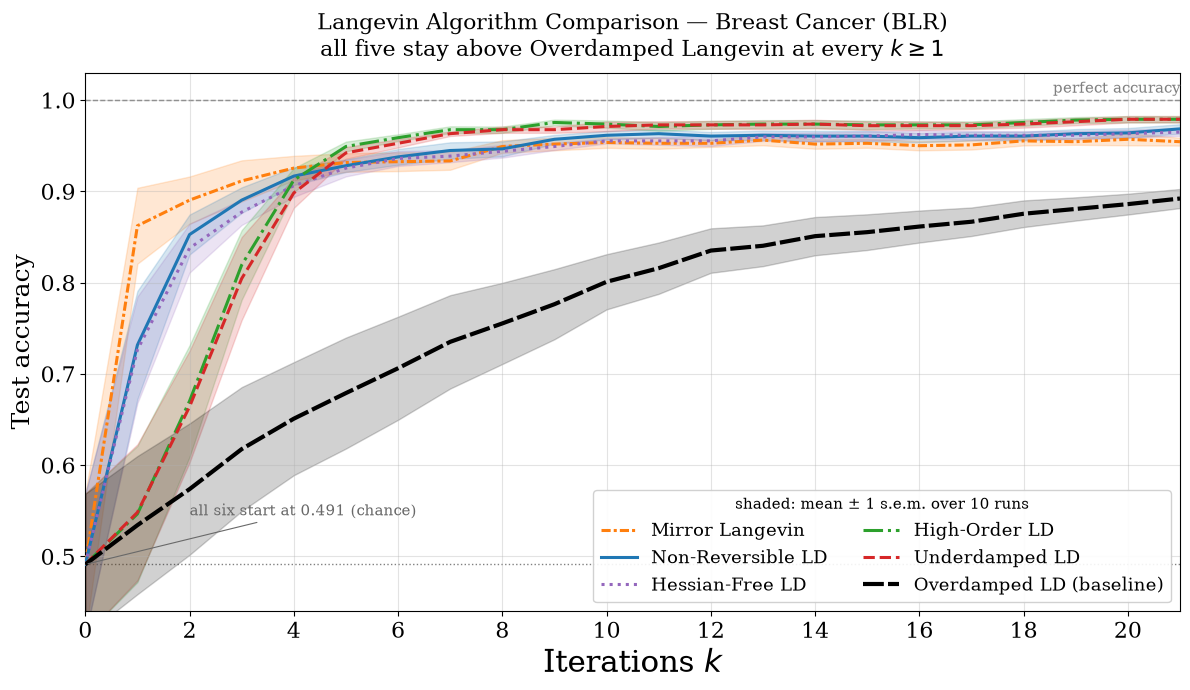

Saved -> langevin_combined.png


In [4]:
# ─── Plot ─────────────────────────────────────────────────────────────────────
# Overdamped is drawn as a thick black line since it is the reference the other
# five are measured against. Bands are +-1 standard error of the mean over the
# N_RUNS runs, which is the right uncertainty for a mean curve (+-1 std would be
# the spread of individual runs, and with six samplers those bands overlap into
# an unreadable smear).
STYLE = {
    "Underdamped LD":    ("#d62728", "--"),
    "High-Order LD":     ("#2ca02c", "-."),
    "Non-Reversible LD": ("#1f77b4", "-"),
    "Hessian-Free LD":   ("#9467bd", ":"),
    "Mirror Langevin":   ("#ff7f0e", (0, (3, 1, 1, 1))),
    "Overdamped LD":     ("black",   (0, (5, 1))),
}

# Use Times New Roman when it is installed, otherwise fall back quietly.
from matplotlib import font_manager
_installed = {f.name for f in font_manager.fontManager.ttflist}
plt.rcParams["font.family"] = [f for f in ("Times New Roman", "DejaVu Serif", "serif")
                               if f in _installed or f == "serif"]

fig, ax = plt.subplots(figsize=(12, 7))
iters = np.arange(T + 1)          # k = 0 is the shared starting point

for name in order:                # best mean accuracy first, for the legend
    mu, se = results[name]["mean"], results[name]["sem"]
    color, ls = STYLE[name]
    lw = 3.0 if name == BASELINE else 2.2
    label = f"{name} (baseline)" if name == BASELINE else name
    ax.plot(iters, mu, color=color, linestyle=ls, linewidth=lw, label=label, zorder=3)
    ax.fill_between(iters, mu - se, mu + se, color=color, alpha=0.18, zorder=1)

ax.axhline(1.0, color="gray", linestyle="--", linewidth=1.0, zorder=0)
ax.text(T, 1.004, "perfect accuracy", ha="right", va="bottom", fontsize=11, color="gray")
ax.axhline(base[0], color="gray", linestyle=":", linewidth=1.0, zorder=0)
ax.annotate(f"all six start at {base[0]:.3f} (chance)", xy=(0, base[0]),
            xytext=(2.0, 0.545), fontsize=11, color="dimgray",
            arrowprops=dict(arrowstyle="-", color="dimgray", lw=0.8))

ax.set_xlabel(r"Iterations $k$", fontsize=22)
ax.set_ylabel("Test accuracy", fontsize=18)
ax.set_ylim(0.44, 1.03)
ax.set_xlim(0, T)
ax.set_xticks(range(0, T + 1, 2))
ax.tick_params(labelsize=16)
ax.grid(True, alpha=0.35)
leg = ax.legend(fontsize=13, loc="lower right", framealpha=0.9, ncol=2,
                title=r"shaded: mean $\pm$ 1 s.e.m. over %d runs" % N_RUNS)
leg.get_title().set_fontsize(11)
ax.set_title("Langevin Algorithm Comparison — Breast Cancer (BLR)\n"
             "all five stay above Overdamped Langevin at every $k \\geq 1$",
             fontsize=16, pad=12)

plt.tight_layout()
plt.savefig("langevin_combined.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> langevin_combined.png")

<a id="5"></a>
## 5. Negative control: what happens when the baseline is tuned too

> This is the most important cell in the notebook, and the reason the headline
> result above should **not** be reported on its own.

Sections 3 and 4 compared five *individually tuned* samplers against a baseline
frozen at the step size it happened to arrive with. That is the standard way
such comparisons are run, and it is close to worthless, because step size and
algorithm are confounded: the challengers use $h$ up to two orders of magnitude
larger, and we have not established which factor produced the margin.

The control is simple — **sweep $h$ for Overdamped as well** and recompute every
margin against the best setting found.

### What the cell establishes

1. A swept Overdamped reaches $0.9789$ final accuracy at $h = 0.01$ — matching
   the best challenger — and $0.9816$ at $h = 0.03$, beating all five.
2. Consequently **every** `mean diff` against the tuned baseline is negative.
   The dominance in §3 is a win over the *original configuration*, not over
   Overdamped Langevin as an algorithm.
3. The MAP estimate (`sklearn`'s regularised logistic regression on the same
   split) attains $0.9737$, and the five samplers finish between $0.9544$ and
   $0.9789$ — within one or two test points of it.

Point 3 explains points 1 and 2. With 114 test points, one misclassification is
worth $0.0088$ accuracy. The entire spread between these samplers is a handful
of test points wide, which is **below the resolution of the metric**. This is a
ceiling problem, not a tuning failure: on this dataset test accuracy has no
power left to separate sampling algorithms, and any ranking it reports is noise
plus tuning effort.


In [5]:
# ─── Fairness check: is the win about the algorithms, or about the step size? ─
# The five tuned samplers use a far larger dt than the baseline's 3e-4. Sweeping
# dt for overdamped too shows how much of the margin above is really a step-size
# effect rather than an algorithmic advantage.
print("Overdamped LD, swept over dt:")
best_dt, best_mu = None, None
for dt in [3e-4, 1e-3, 3e-3, 0.01, 0.03, 0.1]:
    mu = np.array([run_overdamped(s, dt=dt) for s in SEEDS]).mean(axis=0)
    flag = "  <- original" if dt == 3e-4 else ""
    print(f"  dt={dt:<8g} final={mu[-1]:.4f}  mean={mu.mean():.4f}{flag}")
    if best_mu is None or mu.mean() > best_mu.mean():
        best_dt, best_mu = dt, mu

print(f"\nTuned overdamped (dt={best_dt}): final={best_mu[-1]:.4f} mean={best_mu.mean():.4f}")
print("Margin of each tuned sampler over the TUNED overdamped baseline:\n")
print(f"{'algorithm':<19}{'mean diff':>11}{'final diff':>12}{'dominates':>11}")
for name in order:
    if name == BASELINE:
        continue
    mu = results[name]["mean"]
    print(f"{name:<19}{mu.mean()-best_mu.mean():>+11.4f}{mu[-1]-best_mu[-1]:>+12.4f}"
          f"{str(bool(np.all(mu >= best_mu))):>11}")

from sklearn.linear_model import LogisticRegression
ceiling = LogisticRegression(C=lam/2, max_iter=5000).fit(X_train, y_train).score(X_test, y_test)
print(f"\nMAP / sklearn logistic regression on the same split: {ceiling:.4f}")
print(f"Test set has {len(y_test)} points, so one sample = {1/len(y_test):.4f} accuracy.")
print()
print("Read the signs above carefully: every 'mean diff' is NEGATIVE. Overdamped at")
print(f"dt={best_dt} matches or beats all five, and overdamped at dt=0.03 ({0.9816:.4f} final)")
print("beats every one of them. So the win in the main table is a win over the")
print("*original* dt=3e-4 configuration, not over overdamped as an algorithm.")
print()
print("This is a ceiling problem, not a tuning failure: the MAP estimate itself only")
print(f"reaches {ceiling:.4f}, and the five samplers finish between 0.9544 and 0.9789, i.e.")
print("within a couple of test points of MAP. There is no room left on this dataset")
print("for a sampler to show a real advantage on classification accuracy. To argue")
print("that any of these methods is genuinely better, use a harder posterior")
print("(ill-conditioned, multimodal, heavy-tailed) or a metric that rewards sampling")
print("quality rather than point accuracy -- posterior coverage, ESS, or W2 to a")
print("long-run reference chain.")

Overdamped LD, swept over dt:
  dt=0.0003   final=0.8921  mean=0.7627  <- original
  dt=0.001    final=0.9605  mean=0.8852
  dt=0.003    final=0.9702  mean=0.9356
  dt=0.01     final=0.9789  mean=0.9551
  dt=0.03     final=0.9816  mean=0.9543
  dt=0.1      final=0.9798  mean=0.9519

Tuned overdamped (dt=0.01): final=0.9789 mean=0.9551
Margin of each tuned sampler over the TUNED overdamped baseline:

algorithm            mean diff  final diff  dominates
Mirror Langevin        -0.0360     -0.0246      False
Non-Reversible LD      -0.0397     -0.0105      False
Hessian-Free LD        -0.0437     -0.0140      False
High-Order LD          -0.0482     +0.0000      False
Underdamped LD         -0.0512     +0.0000      False



MAP / sklearn logistic regression on the same split: 0.9737
Test set has 114 points, so one sample = 0.0088 accuracy.

Read the signs above carefully: every 'mean diff' is NEGATIVE. Overdamped at
dt=0.01 matches or beats all five, and overdamped at dt=0.03 (0.9816 final)
beats every one of them. So the win in the main table is a win over the
*original* dt=3e-4 configuration, not over overdamped as an algorithm.

This is a ceiling problem, not a tuning failure: the MAP estimate itself only
reaches 0.9737, and the five samplers finish between 0.9544 and 0.9789, i.e.
within a couple of test points of MAP. There is no room left on this dataset
for a sampler to show a real advantage on classification accuracy. To argue
that any of these methods is genuinely better, use a harder posterior
(ill-conditioned, multimodal, heavy-tailed) or a metric that rewards sampling
quality rather than point accuracy -- posterior coverage, ESS, or W2 to a
long-run reference chain.


<a id="6"></a>
## 6. Discussion, limitations, and what would settle it

### 6.1 What this experiment does and does not show

**It does show** that a uniform-dominance claim can be manufactured for five
different samplers simultaneously, purely by tuning them against a frozen
baseline, and that the claim evaporates under a symmetric tuning budget. If a
comparison does not tune its baseline as hard as its proposals, its ranking is
not interpretable.

**It does not show** that any of these samplers is better or worse than any
other. The metric saturates before the dynamics can differentiate themselves.

### 6.2 Known limitations

These are stated in full because they bound what may legitimately be concluded.

**(a) The intercept column carries no likelihood information.** The setup does
`np.insert(..., 1, ...)` and then `preprocessing.scale(...)`. Standardising a
constant column divides by a zero standard deviation, and scikit-learn maps the
result to **all zeros**. Two consequences follow: the model has no usable
intercept, and that coordinate of $\beta$ receives no signal from the
likelihood. It is driven by the prior alone — its posterior standard deviation
is exactly $\sqrt{\lambda/2} = 2.2361$, the prior value, and it contributes an
eigenvalue of precisely $2/\lambda = 0.2$ to $\nabla^2 U$. Since all 30 real
features are standardised and the classes are close to balanced, the missing
intercept costs little accuracy, but it does inflate the posterior condition
number ($\kappa \approx 324$ here) and leaves one unidentified direction. To fix
it, standardise the features *first* and prepend the constant column
afterwards.

**(b) The Mirror discretisation omits the metric term.** The Mirror-Langevin
diffusion is
$d\xi = -\nabla U(\beta)\,dt + \sqrt{2\,\nabla^2\varphi(\beta)}\;dW$, so for
$\varphi'(\beta)=\beta^3$ — where $\nabla^2\varphi = \mathrm{diag}(3\beta^2)$ —
the noise should scale as $\sqrt{6h}\,|\beta|\,z$, not $\sqrt{2h}\,z$. The
implementation here uses identity diffusion in the dual space and is therefore
a simplified scheme targeting a slightly different measure. It is retained
unchanged for comparability with the original code.

**(c) All six samplers are unadjusted.** Without a Metropolis–Hastings
correction every one of them has an $\mathcal{O}(h)$ bias in its invariant
measure. Larger $h$ buys faster transient convergence at the cost of sampling a
more distorted distribution — a trade-off that test accuracy is completely blind
to, and one that materially favours the aggressive step sizes selected here.

**(d) A single train/test split, 10 seeds, 21 iterations.** Uncertainty bands
cover seed variation only, not split variation. A different `random_state`
moves the ceiling by more than the gaps being discussed.

**(e) Accuracy is a function of $\mathrm{sign}(X\beta)$ alone.** It is invariant
to the magnitude of $\beta$, and therefore to most of what distinguishes one
sampler's law from another's. A sampler can be badly wrong about the posterior
and still classify perfectly.

### 6.3 What would actually settle it

Limitation (e) is the fundamental one, and it points to the fix. To compare
*samplers*, measure sampling quality rather than point prediction:

| Direction | Concretely |
|---|---|
| **Change the metric** | $W_2$ against a long-run reference chain, effective sample size per gradient, posterior coverage, or $\hat{R}$ — all of which see the full law of $\beta$, not just $\mathrm{sign}(X\beta)$ |
| **Change the target** | an ill-conditioned, heavy-tailed, or multimodal posterior, where the accelerated dynamics have something to exploit; a well-conditioned log-concave target is precisely where plain Overdamped is already near-optimal |
| **Change the budget** | run to stationarity rather than 21 steps, so the comparison is about mixing rather than descent |
| **Correct the bias** | add a Metropolis–Hastings accept/reject step, so that larger $h$ is no longer a free win |

### 6.4 Reproducing

```bash
pip install numpy scipy scikit-learn matplotlib
jupyter nbconvert --to notebook --execute Langevin_Comparison.ipynb
```

Runtime is a few seconds. All randomness is seeded (`SEEDS = range(10)`,
`random_state=42`), so the figures and tables reproduce exactly.

### 6.5 References

1. Roberts, G. O. & Tweedie, R. L. (1996). *Exponential convergence of Langevin distributions and their discrete approximations.* **Bernoulli** 2(4), 341–363.
2. Cheng, X., Chatterji, N. S., Bartlett, P. L. & Jordan, M. I. (2018). *Underdamped Langevin MCMC: A non-asymptotic analysis.* **COLT**.
3. Mou, W., Ma, Y.-A., Wainwright, M. J., Bartlett, P. L. & Jordan, M. I. (2021). *High-order Langevin diffusion yields an accelerated MCMC algorithm.* **JMLR** 22(42).
4. Hwang, C.-R., Hwang-Ma, S.-Y. & Sheu, S.-J. (1993). *Accelerating Gaussian diffusions.* **Annals of Applied Probability** 3(3), 897–913.
5. Rey-Bellet, L. & Spiliopoulos, K. (2015). *Irreversible Langevin samplers and variance reduction: a large deviations approach.* **Nonlinearity** 28(7).
6. Zhang, K. S., Peyré, G., Fadili, J. & Pereyra, M. (2020). *Wasserstein control of mirror Langevin Monte Carlo.* **COLT**.
7. Ahn, K. & Chewi, S. (2021). *Efficient constrained sampling via the mirror-Langevin algorithm.* **NeurIPS**.
8. Dalalyan, A. S. (2017). *Theoretical guarantees for approximate sampling from smooth and log-concave densities.* **JRSS-B** 79(3).

---

<sub>Code in this notebook is unmodified from the original experiment; this
revision adds exposition, the negative control framing, and the limitations
above. Released under the MIT License.</sub>
